In [1]:
%cd /home/kawamanmi/Projects/PyBaMM
import pybamm
import numpy as np

# Stadardised Formation Cycling Bham group
# no_cycles = 1
# exp = pybamm.Experiment( [("Charge at C/20 until 4.2 V",
#                            "Hold at 4.2 V for 1 hours", 
#                            "Hold at 4.2 V until 2.5 mA", 
#                            "Discharge at C/20 until 2.5 V",
#                            "Charge at C/20 until 3.8 V",
#                            "Hold at 3.8 V for 1 hours"
#                            )]* no_cycles)

no_cycles = 5
exp = pybamm.Experiment(
    [("Charge at C/20 until 4.2 V",
      "Rest for 5 hours",
      "Discharge at C/20 until 2.5 V",
      "Rest for 5 hours",
      )]* no_cycles )
# The SEI layer considered as one layer here, 
# so in all equations if there were Outer_or inner they have been removed
sei_options = [ "ec reaction limited", "ec reaction limited", "ec reaction limited",  "electron-migration limited",  "interstitial-diffusion limited", "tunnelling limited" , "Kolzenberg2020" ]
labels_sei_options = ["RL", "DL", "Mixed", "EM", "ID", "ET", "VK"]  


k_sei =[ 7.0e-13, 1e-7, 1e-10, 1, 1, 7.0e-13, 1]
D_sol = [1e-14,1e-22, 0.8e-22, 1, 1, 1e-14, 1 ]
params = []
for i in range(0, len(k_sei)):
  param=pybamm.ParameterValues("Chen2020")
  param.update({'Initial inner SEI thickness [m]':5e-13,
    'Initial outer SEI thickness [m]':5e-13,
    'SEI kinetic rate constant [m.s-1]':k_sei[i],
    'Outer SEI solvent diffusivity [m2.s-1]':D_sol[i],
    'Bulk solvent concentration [mol.m-3]': 4541.0,
    'Inner SEI electron conductivity [S.m-1]': 8.95e-15, 
    'SEI lithium ion conductivity [S.m-1]': 1.0e-7, 
    'Inner SEI lithium interstitial diffusivity [m2.s-1]': 1e-20, 
    'Lithium interstitial reference concentration [mol.m-3]': 1000,
    }
              )
  params.append(param)
# setup pybamm model to includ SEI models as well
models = [pybamm.lithium_ion.SPM({"particle": "uniform profile",
                                  "SEI": sei_option}) for sei_option in sei_options]

pybamm.settings.max_y_value = 100000000
solver = pybamm.CasadiSolver(mode="safe")

sims = [pybamm.Simulation(model, parameter_values=params[index],
                          experiment=exp, solver=solver) for index, model in enumerate(models)]
sols = [sim.solve(initial_soc=0) for sim in sims]


/home/kawamanmi/.local/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/home/kawamanmi/Projects/PyBaMM


/home/kawamanmi/Projects/formation/comparison_SEI_zero_models


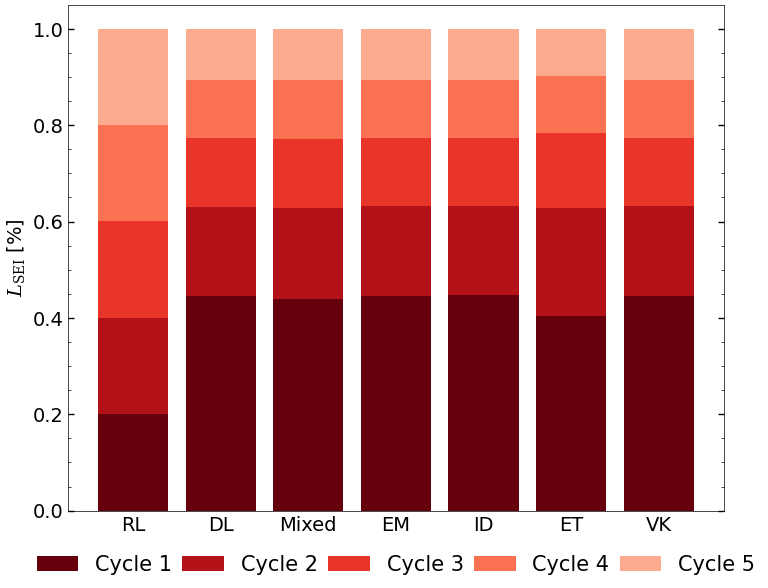

In [2]:
# %cd -
%cd /home/kawamanmi/Projects/formation/comparison_SEI_zero_models
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import scienceplots
import matplotlib.ticker as ticker
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


from style_figs import set_plotting_format

set_plotting_format("paper")  # input should be either "presentation" or "paper"


label_models = ["RL","DL","Mixed",'EM','ID','ET',"VK"]

LL_values_by_sol = [[] for _ in range(len(sols))]

for index, sol in enumerate(sols):
    L_max_total = sols[index]['X-averaged negative total SEI thickness [m]'].entries[-1]
    for cycle in range(no_cycles):
        L_min_cycle = sol.cycles[cycle]['X-averaged negative total SEI thickness [m]'].entries[0]
        LL_max_cycle = sol.cycles[cycle]['X-averaged negative total SEI thickness [m]'].entries[-1]
        LL = (LL_max_cycle - L_min_cycle) / L_max_total
        LL_values_by_sol[index].append(LL)


fig, ax = plt.subplots(figsize=(8, 6))

x = np.arange(len(sols))
bottom = np.zeros(len(sols))

colors = plt.cm.Reds(np.linspace(1, 0.3, no_cycles))


for cycle in range(no_cycles):
    LL_values_cycle = [LL_values_by_sol[sol_index][cycle]
                       for sol_index in range(len(sols))]
    ax.bar(x, LL_values_cycle, bottom=bottom,
           label=f'Cycle {cycle+1}', color=colors[cycle])
    bottom += LL_values_cycle

ax.set_ylabel('$L_\mathrm{SEI}$ [%]', fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.set_xticks(x)
ax.set_xticklabels([label for label in labels_sei_options], fontsize=14)
ax.tick_params(axis='x', which='both', bottom=False,
               top=False)  # remove x-axis ticks
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05),
          fancybox=True, shadow=True, ncol=5, fontsize=15, columnspacing=0.5)


plt.tight_layout()
plt.savefig("figures/fig4.png", dpi=300)